In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load the full 4-feature Iris dataset
iris = datasets.load_iris()
X = iris.data  # Sepal length, sepal width, petal length, petal width
y = iris.target

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset loaded successfully.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Dataset loaded successfully.
Training set shape: (120, 4)
Testing set shape: (30, 4)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled to mean=0 and variance=1.")

Features scaled to mean=0 and variance=1.


In [ ]:
# Initializing SVM with an RBF kernel
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_classifier.fit(X_train_scaled, y_train)



SVC(random_state=42)

In [ ]:
y_pred = svm_classifier.predict(X_test_scaled)

print("=== MODEL EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

=== MODEL EVALUATION ===
Accuracy: 96.67%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
# New samples: [sepal length, sepal width, petal length, petal width]
new_flowers = np.array([
    [5.1, 3.5, 1.4, 0.2],  # Expected: setosa
    [6.5, 3.0, 5.2, 2.0]   # Expected: virginica
])

# Scale the new data using the original scaler
new_flowers_scaled = scaler.transform(new_flowers)

# Make predictions
new_predictions = svm_classifier.predict(new_flowers_scaled)

print("=== NEW DATA PREDICTIONS ===")
for i, pred in enumerate(new_predictions):
    print(f"Flower {i+1} {new_flowers[i]} -> Predicted Species: {iris.target_names[pred].upper()}")

=== NEW DATA PREDICTIONS ===
Flower 1 [5.1 3.5 1.4 0.2] -> Predicted Species: SETOSA
Flower 2 [6.5 3.  5.2 2. ] -> Predicted Species: VIRGINICA


Generating 2D Visualization (using Sepal Features)...


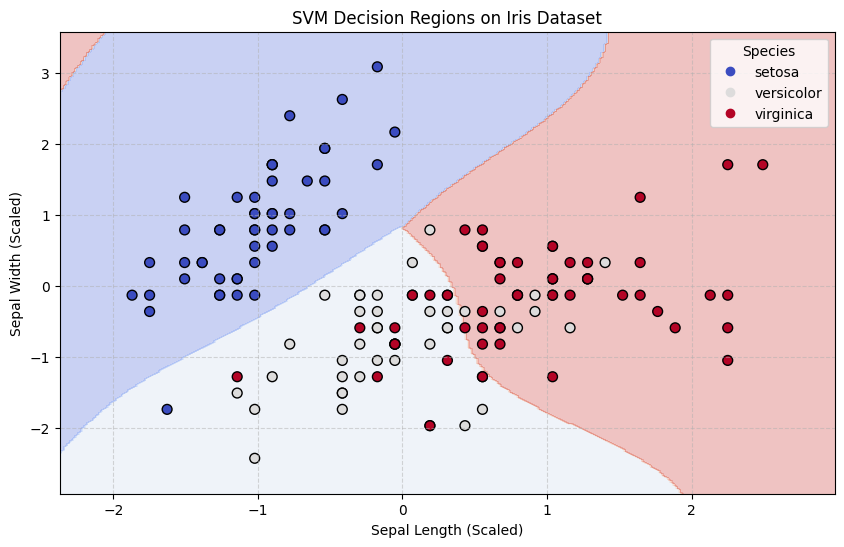

In [ ]:
print("Generating 2D Visualization (using Sepal Features)...")

# We train a separate 2D SVM just for visual layout purposes
X_visual = iris.data[:, :2] # Grab only first two columns (Sepal Length & Width)
scaler_visual = StandardScaler()
X_visual_scaled = scaler_visual.fit_transform(X_visual)

svm_visual = SVC(kernel='rbf', C=1.0, random_state=42)
svm_visual.fit(X_visual_scaled, y)

# Create a grid mesh
x_min, x_max = X_visual_scaled[:, 0].min() - 0.5, X_visual_scaled[:, 0].max() + 0.5
y_min, y_max = X_visual_scaled[:, 1].min() - 0.5, X_visual_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Predict background grid points
Z = svm_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot everything
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_visual_scaled[:, 0], X_visual_scaled[:, 1], c=y,
                      cmap=plt.cm.coolwarm, edgecolors='k', s=50)

plt.xlabel('Sepal Length (Scaled)')
plt.ylabel('Sepal Width (Scaled)')
plt.title('SVM Decision Regions on Iris Dataset')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names), title="Species")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()